In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Crear carpeta de salida
os.makedirs("output", exist_ok=True)

ruta = 'data/2020_Accidentalidad.csv'
df = pd.read_csv(ruta, sep=";")
df.head()

,Nº EXPEDIENTE,FECHA,HORA,CALLE,NÚMERO,DISTRITO,TIPO ACCIDENTE,ESTADO METEREOLÓGICO,TIPO VEHÍCULO,TIPO PERSONA,RANGO DE EDAD,SEXO,LESIVIDAD*,Unnamed: 13,Unnamed: 14
0,2020S000057,01/01/2020,23:15,AVDA. CIUDAD DE BARCELONA / CALL. DOCTOR ESQUERDO,-,RETIRO,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,DE 25 A 29 AÑOS,Hombre,NaN,NaN,NaN
1,2020S000038,01/01/2020,22:35,CALL. VALLE DE TORANZO / CALL. SIERRA DE PAJAREJO,-,MONCLOA-ARAVACA,Caída,Despejado,Ciclomotor,Conductor,DE 21 A 24 AÑOS,Mujer,6.0,NaN,NaN
2,2020S000060,01/01/2020,20:15,GTA. MARIANO SALVADOR MAELLA,1,FUENCARRAL-EL PARDO,Caída,Despejado,Turismo,Conductor,DE 45 A 49 AÑOS,Hombre,14.0,NaN,NaN
3,2020S000060,01/01/2020,20:15,GTA. MARIANO SALVADOR MAELLA,1,FUENCARRAL-EL PARDO,Caída,Despejado,Motocicleta hasta 125cc,Conductor,DE 25 A 29 AÑOS,Hombre,7.0,NaN,NaN
4,2020S000033,01/01/2020,19:45,CALL. OLIVAR,40,CENTRO,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,DESCONOCIDA,NaN,NaN,NaN,NaN


In [57]:
print("Dimensiones (filas, columnas):", df.shape)
print("\nTipos de datos:\n")
df.info()

Dimensiones (filas, columnas): (28773, 15)

Tipos de datos:

<class 'pandas.DataFrame'>
RangeIndex: 28773 entries, 0 to 28772
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Nº  EXPEDIENTE        28773 non-null  str    
 1   FECHA                 28773 non-null  str    
 2   HORA                  28773 non-null  str    
 3   CALLE                 28773 non-null  str    
 4   NÚMERO                28771 non-null  str    
 5   DISTRITO              28771 non-null  str    
 6   TIPO ACCIDENTE        28740 non-null  str    
 7   ESTADO METEREOLÓGICO  25964 non-null  str    
 8   TIPO VEHÍCULO         28633 non-null  str    
 9   TIPO PERSONA          28746 non-null  str    
 10  RANGO DE EDAD         28773 non-null  str    
 11  SEXO                  25398 non-null  str    
 12  LESIVIDAD*            15718 non-null  float64
 13  Unnamed: 13           0 non-null      float64
 14  Unnamed: 14         

In [58]:
memoria_bytes = df.memory_usage(deep=True).sum()
memoria_mb = memoria_bytes / (1024 ** 2)

print(f"Tamaño en memoria: {memoria_bytes} bytes")
print(f"Tamaño en memoria: {memoria_mb:.4f} MB")

Tamaño en memoria: 22814653 bytes
Tamaño en memoria: 21.7577 MB


In [59]:
target = "GPA"
print("Variable objetivo:", target)

columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nColumnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Variable objetivo: GPA

Columnas numéricas: ['LESIVIDAD*', 'Unnamed: 13']
Columnas categóricas: ['Nº  EXPEDIENTE', 'FECHA', 'HORA', 'CALLE', 'NÚMERO', 'DISTRITO', 'TIPO ACCIDENTE', 'ESTADO METEREOLÓGICO', 'TIPO VEHÍCULO', 'TIPO PERSONA', 'RANGO DE EDAD', 'SEXO', 'Unnamed: 14']


C:\Users\ismae\AppData\Local\Temp\ipykernel_14700\402245533.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [60]:
# Vemos que variables numéricas peuden ser categoricas, por ejemplo tienen 0/1
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

Nº  EXPEDIENTE: 12634 valores únicos
FECHA: 335 valores únicos
HORA: 976 valores únicos
CALLE: 6988 valores únicos
NÚMERO: 470 valores únicos
DISTRITO: 21 valores únicos
TIPO ACCIDENTE: 13 valores únicos
ESTADO METEREOLÓGICO: 7 valores únicos
TIPO VEHÍCULO: 34 valores únicos
TIPO PERSONA: 3 valores únicos
RANGO DE EDAD: 18 valores únicos
SEXO: 2 valores únicos
LESIVIDAD*: 9 valores únicos
Unnamed: 13: 0 valores únicos
Unnamed: 14: 1 valores únicos


In [61]:
# Definir columnas categoricas y numericas continuas
df.columns.tolist()
categoricas_reales = ["Gender", "Ethnicity", "Tutoring", "ParentalSupport", "Extracurricular", "Sports", "Music", "Volunteering", "GradeClass"]
numericas_continuas = ["Age", "StudyTimeWeekly", "Absences", "GPA"]

In [62]:
# Hemos visto que no hay nulos
nulos_abs = df.isnull().sum()
nulos_pct = df.isnull().mean() * 100

tabla_nulos = pd.DataFrame({
    "nulos_absolutos": nulos_abs,
    "nulos_porcentaje": nulos_pct
}).sort_values(by="nulos_porcentaje", ascending=False)

tabla_nulos

,nulos_absolutos,nulos_porcentaje
Unnamed: 13,28773,100.000000
Unnamed: 14,28772,99.996525
LESIVIDAD*,13055,45.372398
SEXO,3375,11.729747
ESTADO METEREOLÓGICO,2809,9.762625
TIPO VEHÍCULO,140,0.486567
TIPO ACCIDENTE,33,0.114691
TIPO PERSONA,27,0.093838
NÚMERO,2,0.006951
DISTRITO,2,0.006951


In [63]:
# estadistico descriptivo
descriptivo = df[numericas_continuas].describe().T
descriptivo.to_csv("output/ej1_descriptivo.csv", encoding="utf-8")
descriptivo

KeyError: "None of [Index(['Age', 'StudyTimeWeekly', 'Absences', 'GPA'], dtype='str')] are in the [columns]"

In [ ]:
estadisticos = pd.DataFrame(index=numericas_continuas)

estadisticos["media"] = df[numericas_continuas].mean()
estadisticos["mediana"] = df[numericas_continuas].median()
estadisticos["moda"] = df[numericas_continuas].mode().iloc[0]
estadisticos["desv_tipica"] = df[numericas_continuas].std()
estadisticos["varianza"] = df[numericas_continuas].var()
estadisticos["min"] = df[numericas_continuas].min()
estadisticos["q1"] = df[numericas_continuas].quantile(0.25)
estadisticos["q2_mediana"] = df[numericas_continuas].quantile(0.50)
estadisticos["q3"] = df[numericas_continuas].quantile(0.75)
estadisticos["max"] = df[numericas_continuas].max()
estadisticos["asimetria"] = df[numericas_continuas].skew()
estadisticos["curtosis"] = df[numericas_continuas].kurtosis()

estadisticos

,media,mediana,moda,desv_tipica,varianza,min,q1,q2_mediana,q3,max,asimetria,curtosis
Age,16.468645,16.000000,15.000000,1.123798,1.262923,15.000000,15.000000,16.000000,17.000000,18.000000,0.035793,-1.372099
StudyTimeWeekly,9.771992,9.705363,0.001057,5.652774,31.953857,0.001057,5.043079,9.705363,14.408410,19.978094,0.050068,-1.135682
Absences,14.541388,15.000000,13.000000,8.467417,71.697157,0.000000,7.000000,15.000000,22.000000,29.000000,-0.026017,-1.176225
GPA,1.906186,1.893393,0.000000,0.915156,0.837510,0.000000,1.174803,1.893393,2.622216,4.000000,0.014526,-0.863277


In [ ]:
q1 = df[target].quantile(0.25)
q3 = df[target].quantile(0.75)
iqr = q3 - q1

print(f"Q1 de {target}: {q1:.4f}")
print(f"Q3 de {target}: {q3:.4f}")
print(f"IQR de {target}: {iqr:.4f}")

Q1 de GPA: 1.1748
Q3 de GPA: 2.6222
IQR de GPA: 1.4474


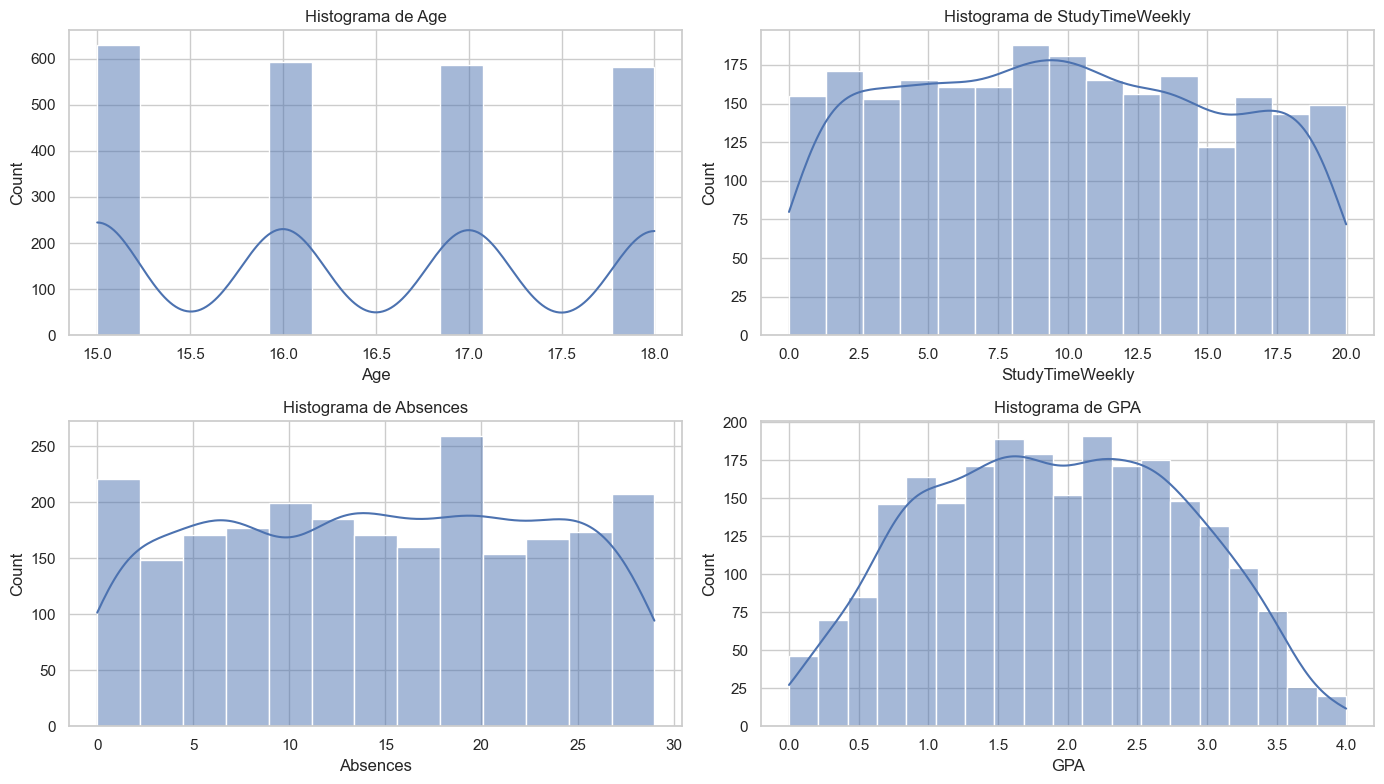

In [ ]:
n = len(numericas_continuas)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numericas_continuas):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Histograma de {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/ej1_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

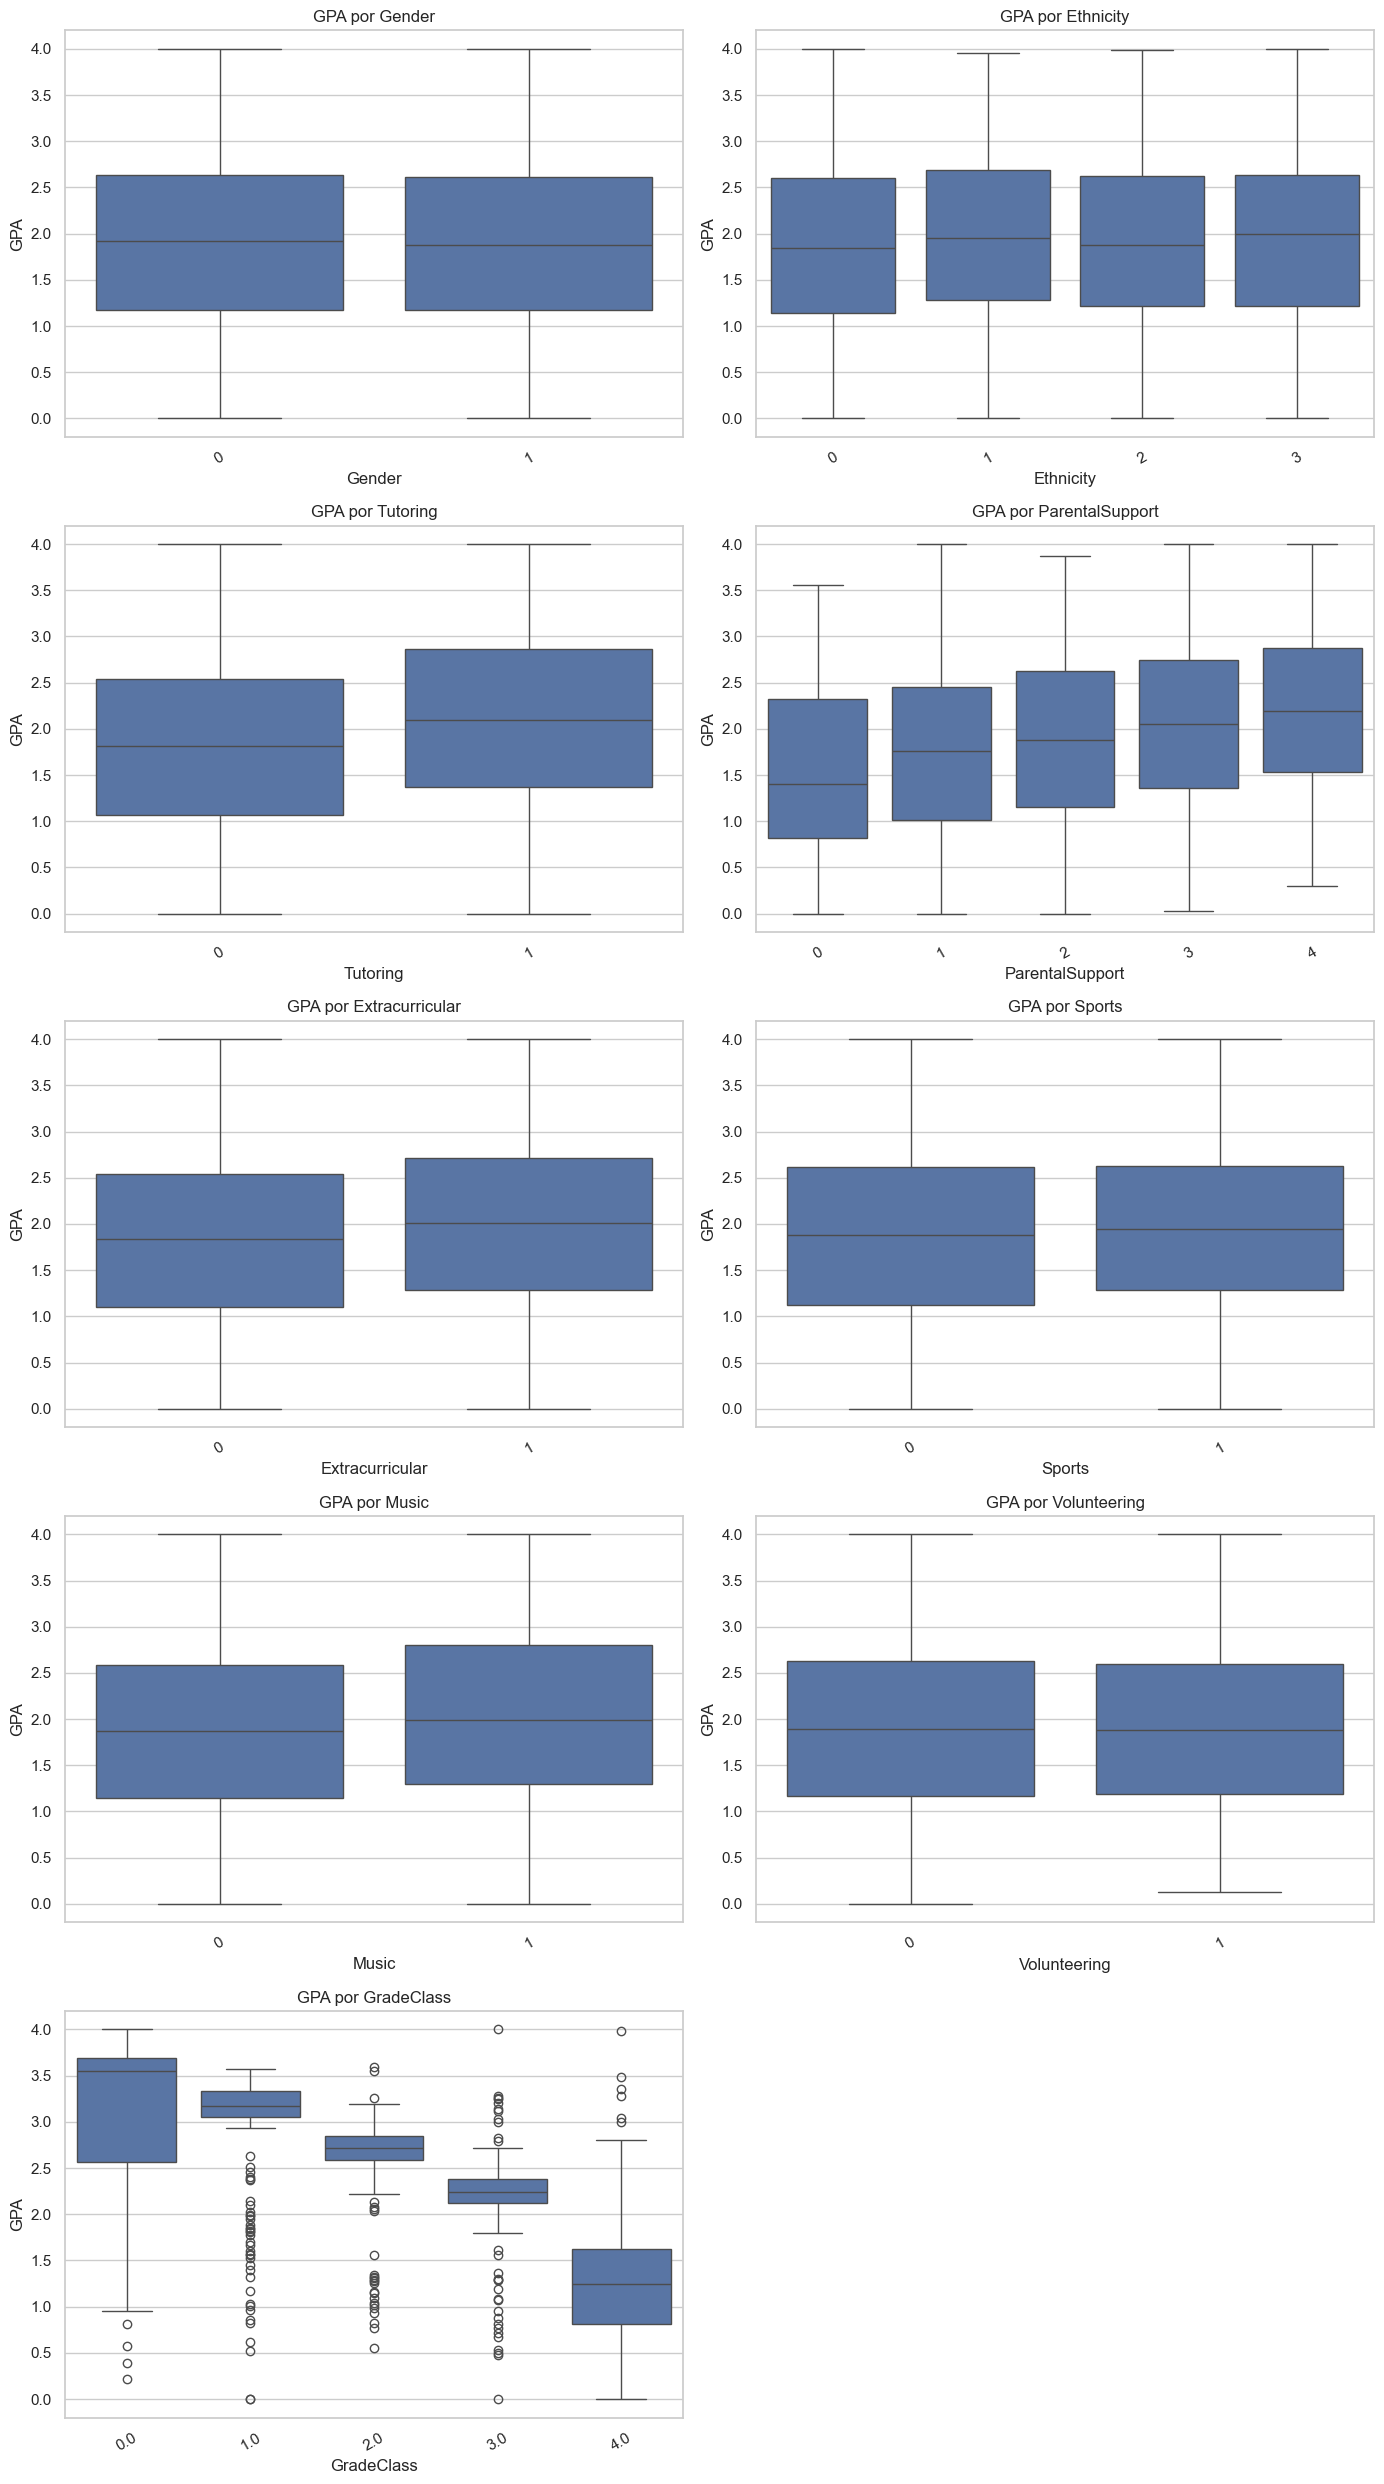

In [ ]:
n = len(categoricas_reales)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categoricas_reales):
    sns.boxplot(data=df, x=col, y=target, ax=axes[i])
    axes[i].set_title(f"{target} por {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/ej1_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
outliers_resumen = []

for col in numericas_continuas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mask_outliers = (df[col] < limite_inferior) | (df[col] > limite_superior)
    n_outliers = mask_outliers.sum()
    pct_outliers = mask_outliers.mean() * 100

    outliers_resumen.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": n_outliers,
        "pct_outliers": pct_outliers
    })

outliers_df = pd.DataFrame(outliers_resumen)
outliers_df

,variable,q1,q3,iqr,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Age,15.000000,17.000000,2.000000,12.000000,20.000000,0,0.0
1,StudyTimeWeekly,5.043079,14.408410,9.365330,-9.004916,28.456405,0,0.0
2,Absences,7.000000,22.000000,15.000000,-15.500000,44.500000,0,0.0
3,GPA,1.174803,2.622216,1.447413,-0.996316,4.793335,0,0.0


In [ ]:
for col in categoricas_reales:
    print(f"\n--- {col} ---")
    print("Frecuencia absoluta:")
    print(df[col].value_counts(dropna=False))
    print("\nFrecuencia relativa (%):")
    print(df[col].value_counts(normalize=True, dropna=False) * 100)


--- Gender ---
Frecuencia absoluta:
Gender
1    1222
0    1170
Name: count, dtype: int64

Frecuencia relativa (%):
Gender
1    51.086957
0    48.913043
Name: proportion, dtype: float64

--- Ethnicity ---
Frecuencia absoluta:
Ethnicity
0    1207
1     493
2     470
3     222
Name: count, dtype: int64

Frecuencia relativa (%):
Ethnicity
0    50.459866
1    20.610368
2    19.648829
3     9.280936
Name: proportion, dtype: float64

--- Tutoring ---
Frecuencia absoluta:
Tutoring
0    1671
1     721
Name: count, dtype: int64

Frecuencia relativa (%):
Tutoring
0    69.85786
1    30.14214
Name: proportion, dtype: float64

--- ParentalSupport ---
Frecuencia absoluta:
ParentalSupport
2    740
3    697
1    489
4    254
0    212
Name: count, dtype: int64

Frecuencia relativa (%):
ParentalSupport
2    30.936455
3    29.138796
1    20.443144
4    10.618729
0     8.862876
Name: proportion, dtype: float64

--- Extracurricular ---
Frecuencia absoluta:
Extracurricular
0    1475
1     917
Name: count, d

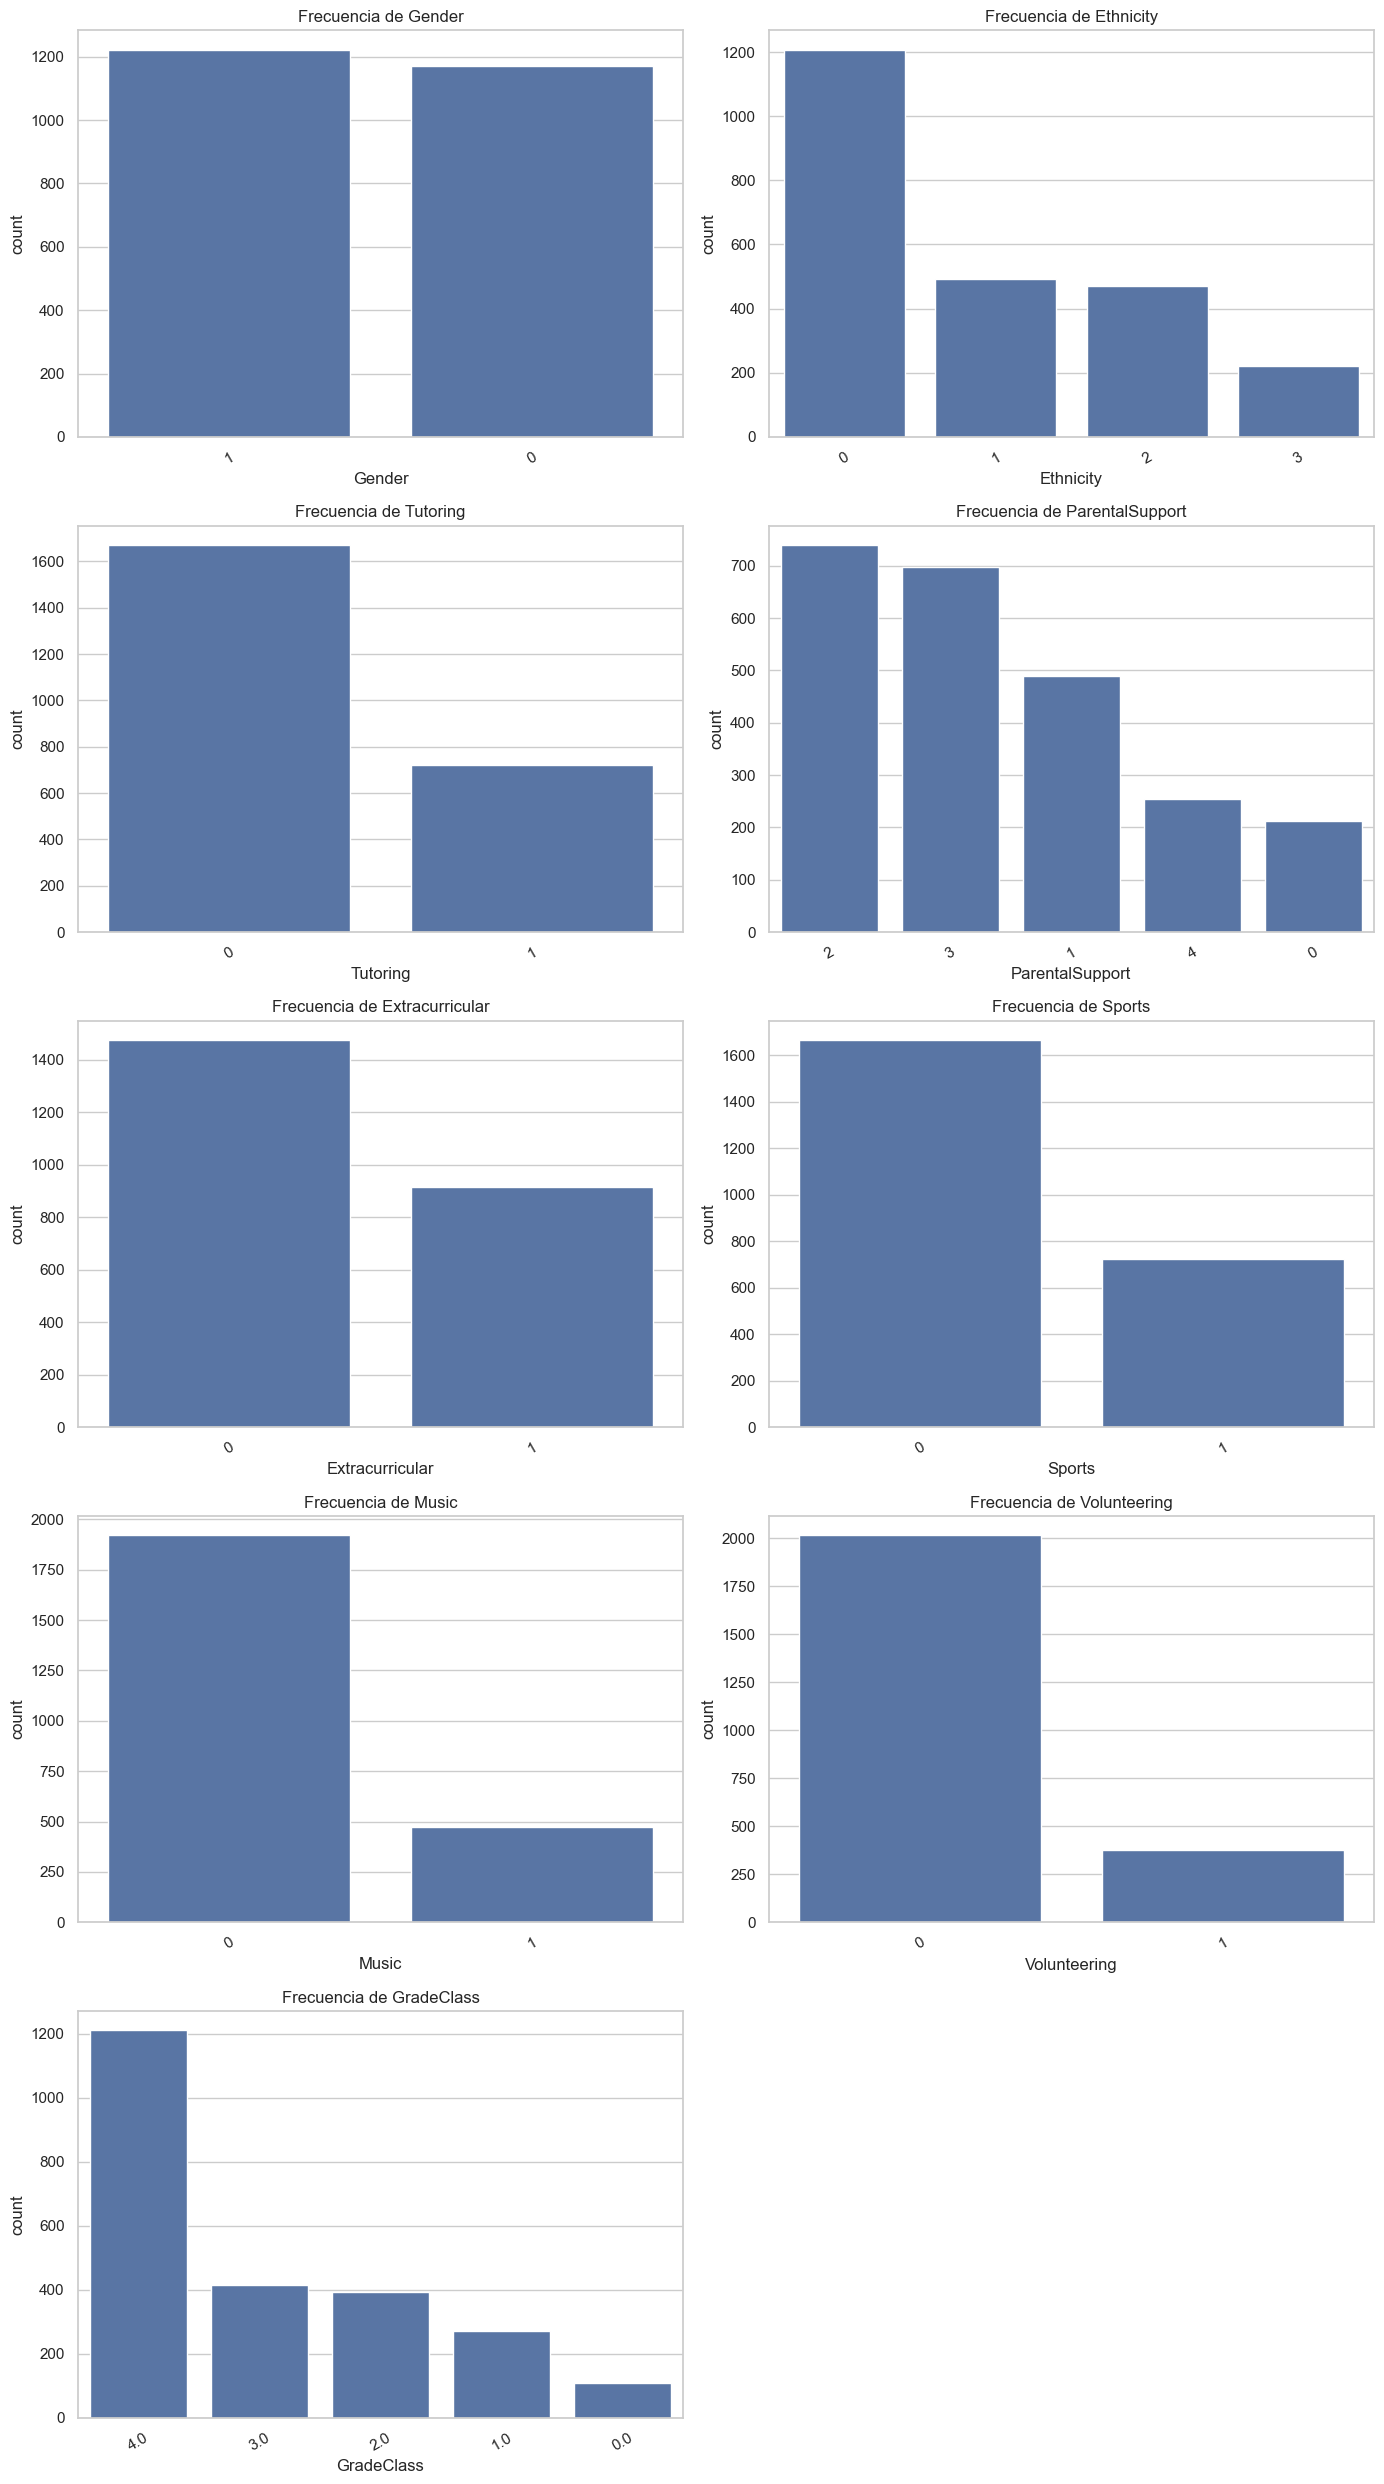

In [ ]:
n = len(categoricas_reales)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categoricas_reales):
    orden = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=orden, ax=axes[i])
    axes[i].set_title(f"Frecuencia de {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("output/ej1_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
corr = df[numericas_continuas].corr(method="pearson")
corr

,Age,StudyTimeWeekly,Absences,GPA
Age,1.000000,-0.006800,-0.011511,0.000275
StudyTimeWeekly,-0.006800,1.000000,0.009326,0.179275
Absences,-0.011511,0.009326,1.000000,-0.919314
GPA,0.000275,0.179275,-0.919314,1.000000


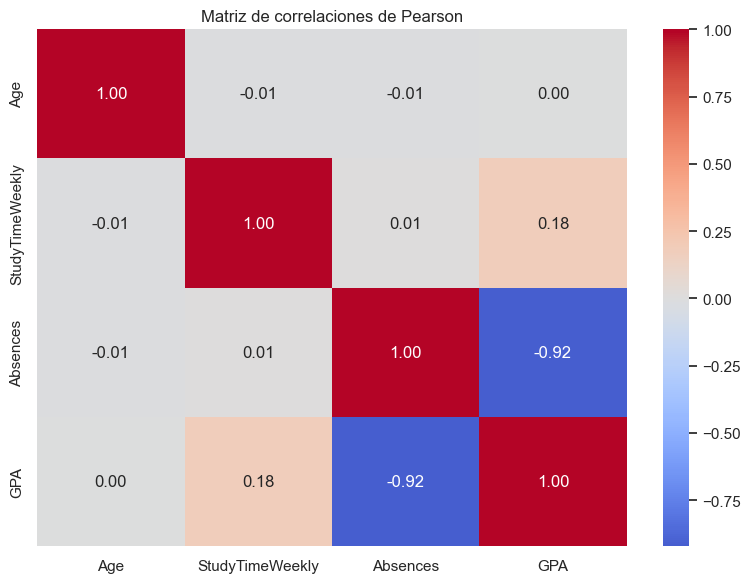

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlaciones de Pearson")
plt.tight_layout()
plt.savefig("output/ej1_heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
corr_target = corr[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
corr_target.head(3)

Absences          -0.919314
StudyTimeWeekly    0.179275
Age                0.000275
Name: GPA, dtype: float64

In [ ]:
corr_abs = corr.abs()

pares_altos = []
cols = corr_abs.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_abs.iloc[i, j] > 0.9:
            pares_altos.append((cols[i], cols[j], corr.iloc[i, j]))

pares_altos

[('Absences', 'GPA', np.float64(-0.9193135764208645))]

In [ ]:
print("RESUMEN DEL ANÁLISIS")
print("-" * 40)
print("Dimensiones:", df.shape)
print(f"Tamaño en memoria: {memoria_mb:.4f} MB")
print("Target:", target)
print("\nNulos:")
print(tabla_nulos)

print("\nTop 3 correlaciones con el target:")
print(top3)

print("\nOutliers detectados:")
print(outliers_df[["variable", "n_outliers", "pct_outliers"]])

RESUMEN DEL ANÁLISIS
----------------------------------------
Dimensiones: (2392, 15)
Tamaño en memoria: 0.2739 MB
Target: GPA

Nulos:
                   nulos_absolutos  nulos_porcentaje
StudentID                        0               0.0
Age                              0               0.0
Gender                           0               0.0
Ethnicity                        0               0.0
ParentalEducation                0               0.0
StudyTimeWeekly                  0               0.0
Absences                         0               0.0
Tutoring                         0               0.0
ParentalSupport                  0               0.0
Extracurricular                  0               0.0
Sports                           0               0.0
Music                            0               0.0
Volunteering                     0               0.0
GPA                              0               0.0
GradeClass                       0               0.0

Top 3 correlacio